<a href="https://colab.research.google.com/github/Aman1477r/ML-journey/blob/main/ML%20%20Day%20%3D%206.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
df = pd.read_csv('height-weight.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight')

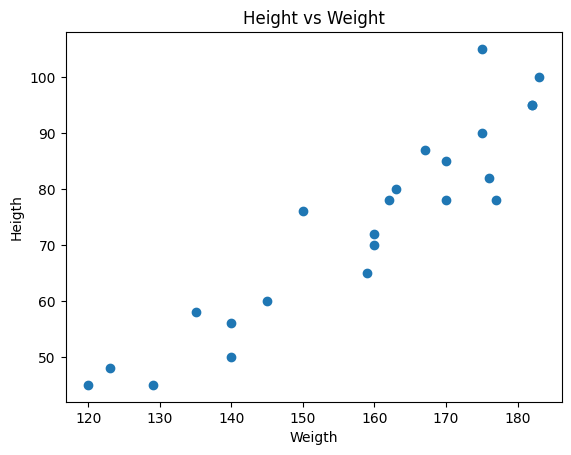

In [9]:
#### SCAterr Plot

plt.scatter(df['Height'],df['Weight'])
plt.xlabel('Weigth')
plt.ylabel('Heigth')
plt.title('Height vs Weight')

In [10]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [11]:
import seaborn as sns

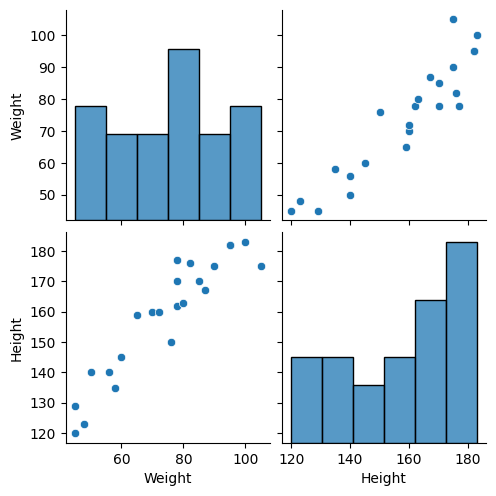

In [14]:
sns.pairplot(df)

In [19]:
## INDEPENDEN And DEPENDENT FEature

X = df[['Weight']]
Y = df['Height']

In [20]:
X.head()
Y.head()

,Height
0,120
1,135
2,123
3,145
4,160


In [17]:
X_seris = df['Weight']

In [18]:
np.array(X_seris).shape

(23,)

In [21]:
### TRAIN TEST SPLIT

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=0)

In [24]:
X_train.shape

(17, 1)

In [25]:
### STANDARIZATION

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [26]:
X_test

array([[ 1.16402338],
       [ 0.40293117],
       [-1.11925325],
       [ 0.57856783],
       [-1.76325435],
       [-1.00216214]])

In [27]:
### APLLY LENEAR REGRATION

In [28]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,Y_train)

LinearRegression()

In [29]:
lr

LinearRegression()

In [30]:
lr.predict(X_test)

array([178.71673229, 166.13271502, 140.96468049, 169.03671901,
       130.31666588, 142.90068314])

In [34]:
print('coificent or slope:',lr.coef_)

coificent or slope: [16.53415595]


In [33]:
lr.intercept_

np.float64(159.47058823529412)

Text(0.5, 1.0, 'Height vs Weight')

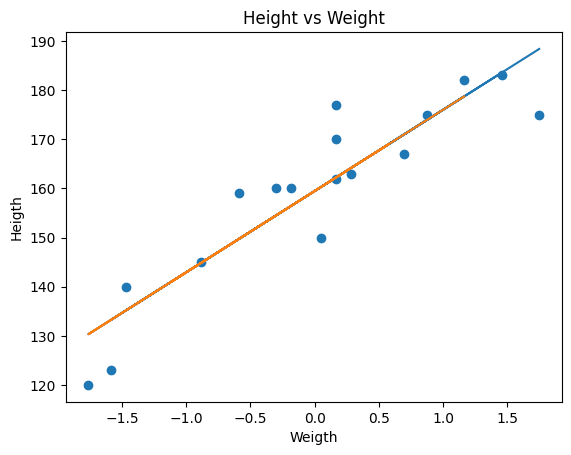

In [37]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,lr.predict(X_train))
plt.plot(X_test,lr.predict(X_test))
plt.xlabel('Weigth')
plt.ylabel('Heigth')
plt.title('Height vs Weight')

In [38]:
### PERFORMANCE MATRIX

from sklearn.metrics import mean_absolute_error,mean_squared_error

In [39]:
mse = mean_squared_error(Y_test,lr.predict(X_test))
mae = mean_absolute_error(Y_test,lr.predict(X_test))
rmse = np.sqrt(mse)
print(rmse)
print(mse)
print(mae)


5.387579566510548
29.02601358548199
4.049310530227544


In [40]:
#### r square

from sklearn.metrics import r2_score
r2_score(Y_test,lr.predict(X_test))

0.935386069188885

In [41]:
### adjusted r square

1-(1-r2_score(Y_test,lr.predict(X_test)))*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.9192325864861063

In [43]:
 ### OLS Technique

 import statsmodels.api as sm
 model = sm.OLS(Y_train,X_train).fit()

In [44]:
predictiom = model.predict(X_test)
print(predictiom)

[ 19.24614406   6.66212679 -18.50590775   9.56613077 -29.15392236
 -16.56990509]


In [45]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.011
Model:                            OLS   Adj. R-squared (uncentered):             -0.051
Method:                 Least Squares   F-statistic:                             0.1716
Date:                Sat, 20 Jun 2026   Prob (F-statistic):                       0.684
Time:                        11:46:31   Log-Likelihood:                         -110.36
No. Observations:                  17   AIC:                                      222.7
Df Residuals:                      16   BIC:                                      223.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:
### prediction for new data